# Alarm Rationalisation with a Generative Model <sup>🚨 ISA-18.2</sup>

**The task on your desk:** the console is annunciating far more than the operator can act on. Hand back an alarm scheme that stays inside **EEMUA-191's budget of 6 alarms per hour** and still catches every upset — with evidence.

This is not an ML exercise dressed in process clothing. Alarm rationalisation is a named deliverable in every operating company, it is audited, and it is the kind of study that follows an incident report. You will produce a scorecard row and defend it.

The data is real: the **3W dataset** published by **Petrobras** — operational data from offshore oil wells, 1 Hz, with expert-labelled undesirable events. We use only the genuinely-measured instances (there are simulated ones in the release; more on that below), and only the six tags present across enough of them.

| | |
|---|---|
| **Corpus** | 263 real well files — 54 labelled upset episodes + 209 normal reference files, 3,331 hours |
| **Tags** | `T-TPT`, `P-TPT`, `P-PDG`, `T-PDG`, `P-MON-CKP`, `P-JUS-CKGL` |
| **Baseline** | a conventional per-tag HH/LL threshold scheme with deadband and on-delay |
| **Challenger** | a diffusion model trained only on normal operation, used to **suppress** alarms per tag |
| **Scorecard** | alarms/hour, missed upsets out of 54, and time to detect |

The honest framing up front: the conventional scheme already misses almost nothing, so the generative model **cannot win on detection**. It can only win by cutting the nuisance rate *without* paying for it in detection latency. Whether it does is an open question when you start this notebook, and a legitimate result either way.

> **Data attribution (CC BY 4.0, required).** 3W Dataset, Petrobras — <https://github.com/petrobras/3W>. Vargas et al., *A realistic and public dataset with rare undesirable real events in oil wells*. Data licensed CC BY 4.0, toolkit Apache-2.0.
>
> **Runtime.** ~15–20 minutes on a Colab T4, including a ~190 MB download. Set *Runtime → Change runtime type → T4 GPU*.

**A domain caveat, stated plainly:** these are offshore wells, not a refinery. The tags are wellhead and subsea-tree pressures and temperatures. The *method* — deriving limits from normal operation, counting annunciations correctly, the rate-versus-latency tradeoff, the bad-actor Pareto — transfers exactly to your units. The tag names do not. We are not going to pretend otherwise.

## Setup

In [1]:
#@title imports
import io, os, math, copy, json, urllib.request
from pathlib import Path
from concurrent.futures import ThreadPoolExecutor

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

np.seterr(all="ignore")
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
torch.manual_seed(0); np.random.seed(0)
print("device:", device, "| torch", torch.__version__)

device: mps | torch 2.8.0


## The data, and the four traps in it

The 3W release is generous and messy, in the way real industrial data is. Four things will silently ruin your numbers if you do not handle them, and each one is worth more to you than the model that comes later.

1. **Half the release is not real.** Of 2,228 instance files, only 1,119 are measured (`WELL-*`); 1,089 are simulated (`SIMULATED_*`) and 20 are hand-drawn by experts (`DRAWN_*`). A student who globs `dataset/*/*.parquet` trains on a 49%-synthetic corpus. We hard-filter to `WELL-*`.
2. **Every file opens with exactly one hour of unlabelled rows.** All 1,119 real files begin with 3,600 rows of `class = NA`, with the process variables partly populated. Left in, they contaminate the design window and shift every percentile limit.
3. **Some labelled fault directories contain no fault.** In `dataset/9/`, 43 of 57 real files carry no class-9 label at all — they are entirely normal. Counting directory entries gives you 57 hydrate events and scores 43 phantom "missed upsets" that never happened.
4. **Alarms are transitions, not samples.** At 1 Hz, counting *samples in alarm* instead of *off→on transitions* inflates the rate by three orders of magnitude. We count edges, and we will show you the difference.

In [2]:
#@title download the 6-channel subset (real instances only)
RAW  = "https://raw.githubusercontent.com/petrobras/3W/main"
root = Path("3w"); root.mkdir(exist_ok=True)

CHANNELS = ["T-TPT", "P-TPT", "P-PDG", "T-PDG", "P-MON-CKP", "P-JUS-CKGL"]
NA_PREFIX = 3600                                          # trap 2

def list_class_files(cls):
    """GitHub API listing for one class directory, real instances only (trap 1)."""
    url = f"https://api.github.com/repos/petrobras/3W/contents/dataset/{cls}?per_page=1000"
    with urllib.request.urlopen(url) as r:
        items = json.loads(r.read().decode())
    return [i["name"] for i in items if i["name"].startswith("WELL-") and i["name"].endswith(".parquet")]

inventory = {}
for cls in [0, 1, 5, 7, 8, 9]:            # normal + the event classes with usable lead-in
    inventory[cls] = list_class_files(cls)
    print(f"  class {cls}: {len(inventory[cls]):3d} real files")
print("real-instance filter applied (trap 1): SIMULATED_* and DRAWN_* excluded")

  class 0: 594 real files


  class 1:   4 real files


  class 5:  11 real files


  class 7:  36 real files


  class 8:  14 real files


  class 9:  57 real files
real-instance filter applied (trap 1): SIMULATED_* and DRAWN_* excluded


In [3]:
#@title fetch the files we need
def fetch(cls, name):
    dst = root / str(cls) / name
    if dst.exists(): return dst
    dst.parent.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(f"{RAW}/dataset/{cls}/{name}", dst)
    return dst

MAX_NORMAL = 120          # plenty for limits + training; keeps the download ~150 MB
jobs = [(0, n) for n in sorted(inventory[0])[:MAX_NORMAL]]
for cls in [1, 5, 7, 8, 9]:
    jobs += [(cls, n) for n in sorted(inventory[cls])]
print(f"fetching {len(jobs)} files ...")
with ThreadPoolExecutor(8) as ex:
    paths = list(tqdm(ex.map(lambda a: fetch(*a), jobs), total=len(jobs)))
mb = sum(p.stat().st_size for p in paths) / 1e6
print(f"downloaded {len(paths)} files, {mb:.0f} MB")

fetching 242 files ...


  0%|          | 0/242 [00:00<?, ?it/s]

downloaded 242 files, 298 MB


In [4]:
#@title load, applying every guard
def load_one(cls, path):
    df = pd.read_parquet(path)
    if df["class"].isna().sum() < NA_PREFIX - 1:      # trap 2 must hold
        return None
    df = df.iloc[NA_PREFIX:]
    if not all(df[c].notna().mean() > 0.9 for c in CHANNELS):
        return None                                    # tag not instrumented on this well
    lab = df["class"].fillna(-1).astype(int).to_numpy()
    if cls > 0:
        hit = np.flatnonzero((lab == cls) | (lab == cls + 100))
        if len(hit) == 0:
            return ("phantom", None)                   # trap 3
        onset = int(hit[0])
    else:
        onset = None
    normal = np.flatnonzero(lab == 0)
    if onset is not None: normal = normal[normal < onset]
    if len(normal) < 3600: return None                 # need >= 1 h of labelled normal
    return ("ok", dict(cls=cls, path=str(path), X=df[CHANNELS].to_numpy(np.float32),
                       onset=onset, normal=normal))

episodes, normals, phantom, skipped = [], [], 0, 0
for cls, name in tqdm(jobs, desc="loading"):
    r = load_one(cls, root / str(cls) / name)
    if r is None: skipped += 1; continue
    tag, rec = r
    if tag == "phantom": phantom += 1; continue
    (normals if cls == 0 else episodes).append(rec)

print(f"\nusable upset episodes : {len(episodes)}")
print(f"normal reference files: {len(normals)}")
print(f"phantom files dropped (trap 3, labelled dir but no label inside): {phantom}")
print(f"files skipped (missing channels or <1 h normal lead-in)         : {skipped}")
print("\nepisodes by class:", pd.Series([e['cls'] for e in episodes]).value_counts().sort_index().to_dict())

loading:   0%|          | 0/242 [00:00<?, ?it/s]


usable upset episodes : 55
normal reference files: 93
phantom files dropped (trap 3, labelled dir but no label inside): 15
files skipped (missing channels or <1 h normal lead-in)         : 79

episodes by class: {1: 3, 5: 7, 7: 25, 8: 7, 9: 13}


## Design and evaluation windows

For each episode the labelled-normal lead-in is split in half:

- the **first half is the design window** — where the alarm limits come from, exactly as an engineer would set them from a period of known-good operation;
- the **second half is the held-out nuisance window** — where we measure alarms per hour, on data the limits never saw;
- everything from the first fault label onward is the **event window**, where we measure detection.

That split is what makes the nuisance rate honest. Setting limits from percentiles of a period and then reporting the alarm rate *on that same period* is the most common way an alarm study flatters itself.

In [5]:
#@title split every episode
def split(rec):
    n = rec["normal"]; k = len(n) // 2
    return dict(**rec, design=n[:k], nuisance=n[k:])

episodes = [split(e) for e in episodes]
normals   = [split(e) for e in normals]
tot_nuis  = sum(len(e["nuisance"]) for e in episodes + normals) / 3600
print(f"held-out nuisance hours: {tot_nuis:,.1f}")
print(f"design hours           : {sum(len(e['design']) for e in episodes+normals)/3600:,.1f}")
lead = np.array([len(e['normal'])/3600 for e in episodes])
print(f"labelled-normal lead-in before onset: median {np.median(lead):.1f} h (min {lead.min():.1f}, max {lead.max():.1f})")

held-out nuisance hours: 439.1
design hours           : 439.1
labelled-normal lead-in before onset: median 4.9 h (min 1.0, max 28.6)


## The conventional scheme

A textbook per-tag alarm, with the three knobs a real DCS gives you:

- **HH / LL limits** from percentiles of the design window;
- a **deadband** so a signal hovering on the limit does not chatter — the alarm clears only when the value returns inside the limit by 1% of range;
- an **on-delay** — the condition must persist for *D* seconds before it annunciates.

The alarm **latches**: it annunciates once on the transition into alarm and does not re-annunciate until it has cleared. We count **annunciations**, which is what reaches the operator.

In [6]:
#@title the alarm engine (vectorised, no Python loop over 12M samples)
def hold_for(cond, D):
    """True where cond has been continuously true for D samples."""
    if D <= 1: return cond.copy()
    c = np.concatenate(([0], np.cumsum(cond.astype(np.int32))))
    out = np.zeros(len(cond), bool)
    out[D-1:] = (c[D:] - c[:len(cond)-D+1]) == D
    return out

def latch(trip, clear):
    ar = np.arange(len(trip))
    return np.maximum.accumulate(np.where(trip, ar, -1)) > np.maximum.accumulate(np.where(clear, ar, -1))

def alarm_state(x, lo, hi, deadband, delay):
    raw   = np.where(np.isnan(x), False, (x > hi) | (x < lo))
    clear = np.where(np.isnan(x), False, (x < hi - deadband) & (x > lo + deadband))
    return latch(hold_for(raw, delay), clear)

def annunciations(state):
    """off -> on transitions. NOT samples-in-alarm."""
    return int(np.count_nonzero(state[1:] & ~state[:-1])) + int(state[0])

def limits(x_design, pct):
    """None when the tag carries no usable data in this design window.
       A tag can be >90% present across a whole file and still be entirely
       absent from one episode's design half - guard, do not assume."""
    d = x_design[~np.isnan(x_design)]
    if len(d) < 100: return None
    lo, hi = np.percentile(d, pct), np.percentile(d, 100 - pct)
    rng = (hi - lo) or (abs(hi) or 1.0)
    return lo, hi, 0.01 * rng

In [7]:
#@title why "count the edges" is not a detail
# pick the first (episode, tag) that actually has limits
for rec in episodes:
    for ci in range(len(CHANNELS)):
        x = rec["X"][:, ci]
        lim = limits(x[rec["design"]], 1.0)
        if lim is not None: break
    if lim is not None: break
lo, hi, db = lim
st = alarm_state(x[rec["nuisance"]], lo, hi, db, 0)
hrs = len(rec["nuisance"]) / 3600
print(f"tag {CHANNELS[ci]}, one episode, {hrs:.1f} h of held-out normal operation\n")
print(f"  samples in alarm      : {int(st.sum()):7,d}  ->  {st.sum()/hrs:10,.0f} 'alarms'/h   (WRONG)")
print(f"  annunciations (edges) : {annunciations(st):7,d}  ->  {annunciations(st)/hrs:10,.2f}  alarms/h   (right)")
print(f"\n  ratio: {st.sum()/max(annunciations(st),1):,.0f}x")

tag T-TPT, one episode, 6.1 h of held-out normal operation

  samples in alarm      :     358  ->          59 'alarms'/h   (WRONG)
  annunciations (edges) :       3  ->        0.49  alarms/h   (right)

  ratio: 119x


In [8]:
#@title the rate-versus-latency tradeoff
def evaluate(pct, delay, recs_ep, recs_nm):
    ann = hrs = 0; ttds = []; missed = 0; standing = []
    for r in recs_ep + recs_nm:
        for ci in range(len(CHANNELS)):
            x = r["X"][:, ci]
            lim = limits(x[r["design"]], pct)
            if lim is None: continue
            lo, hi, db = lim
            ann += annunciations(alarm_state(x[r["nuisance"]], lo, hi, db, delay))
        hrs += len(r["nuisance"]) / 3600
    for r in recs_ep:
        first, latched = None, 0
        for ci in range(len(CHANNELS)):
            x = r["X"][:, ci]
            lim = limits(x[r["design"]], pct)
            if lim is None: continue
            lo, hi, db = lim
            st = alarm_state(x, lo, hi, db, delay)
            o = r["onset"]
            was = bool(st[o-1]) if o > 0 else False
            if was: latched += 1
            idx = np.flatnonzero(st[o:] & ~np.r_[was, st[o:-1]])
            if len(idx): first = int(idx[0]) if first is None else min(first, int(idx[0]))
        standing.append(latched)
        if first is None: missed += 1
        else: ttds.append(first)
    return dict(alarms_per_h=ann/hrs, annunciations=ann, hours=hrs, missed=missed,
                median_ttd=float(np.median(ttds)), mean_ttd=float(np.mean(ttds)),
                latched_at_onset=float(np.mean(standing)))

rows = {}
for pct in [1.0, 0.1]:
    for delay in [0, 30, 60, 120]:
        rows[f"p{pct}/p{100-pct}, {delay:3d}s delay"] = evaluate(pct, delay, episodes, normals)
full  = pd.DataFrame(rows).T
curve = full[["alarms_per_h", "missed", "median_ttd", "mean_ttd", "latched_at_onset"]]
print(f"EEMUA-191 budget = 6 alarms/hour.  {len(episodes)} upset episodes, "
      f"{full.iloc[0]['hours']:.0f} held-out normal hours\n")
print(curve.round(2).to_string())

EEMUA-191 budget = 6 alarms/hour.  55 upset episodes, 439 held-out normal hours

                        alarms_per_h  missed  median_ttd  mean_ttd  latched_at_onset
p1.0/p99.0,   0s delay         25.66     1.0        83.5   2334.11              1.98
p1.0/p99.0,  30s delay          5.64     1.0       239.5   2787.07              1.78
p1.0/p99.0,  60s delay          3.64     1.0       416.0   3221.15              1.69
p1.0/p99.0, 120s delay          2.35     1.0       791.0   5107.89              1.62
p0.1/p99.9,   0s delay         16.69     1.0       148.0   2443.07              1.87
p0.1/p99.9,  30s delay          3.32     1.0       283.0   3400.93              1.69
p0.1/p99.9,  60s delay          2.44     1.0       497.5   5092.85              1.58
p0.1/p99.9, 120s delay          1.79     1.0       855.5   6589.91              1.53


Three things to take from that table.

**The conventional scheme is over budget before you have six tags.** Read the alarms/hour for the loose limits with no delay and divide by six: that is the rate *per tag*. A real console carries 500 to 2,000 tags. Multiply.

**The on-delay is a good knob and it is not free.** It buys the rate down by roughly an order of magnitude, and pays for it in detection latency. That tradeoff curve is the thing to beat — not the no-delay corner.

**The last column is the finding.** `latched_at_onset` is how many of the six tags were *already sitting in alarm* at the instant the upset began. It is close to two. The alarm system is annunciating at much the same rate whether or not anything is wrong, which means the operator has no way to tell the difference. That, and not the raw count, is why alarm floods hurt.

share of all annunciations, tight limits, no delay:

            annunciations  % of total  cumulative %
T-TPT                3794        51.8          51.8
P-TPT                1489        20.3          72.1
P-MON-CKP            1481        20.2          92.3
P-JUS-CKGL            310         4.2          96.5
P-PDG                 135         1.8          98.4
T-PDG                 120         1.6         100.0


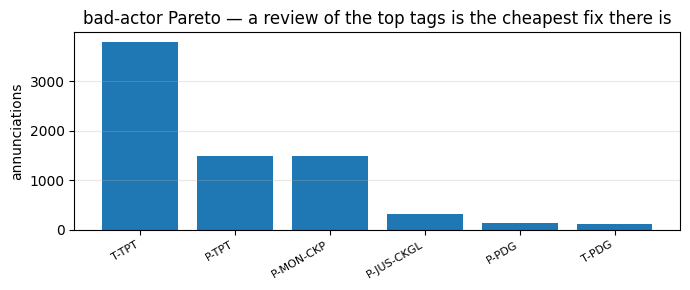

In [9]:
#@title bad actors: which tags are doing this?
per_tag = {c: 0 for c in CHANNELS}
for r in episodes + normals:
    for ci, c in enumerate(CHANNELS):
        x = r["X"][:, ci]
        lim = limits(x[r["design"]], 0.1)
        if lim is None: continue
        lo, hi, db = lim
        per_tag[c] += annunciations(alarm_state(x[r["nuisance"]], lo, hi, db, 0))
pareto = pd.Series(per_tag).sort_values(ascending=False)
pareto_pct = 100 * pareto / pareto.sum()
print("share of all annunciations, tight limits, no delay:\n")
print(pd.DataFrame({"annunciations": pareto, "% of total": pareto_pct.round(1),
                    "cumulative %": pareto_pct.cumsum().round(1)}).to_string())

plt.figure(figsize=(7, 3))
plt.bar(range(len(pareto)), pareto.values)
plt.xticks(range(len(pareto)), pareto.index, rotation=30, ha="right", fontsize=8)
plt.ylabel("annunciations"); plt.title("bad-actor Pareto — a review of the top tags is the cheapest fix there is")
plt.grid(alpha=0.3, axis="y"); plt.tight_layout(); plt.show()

## The challenger: a diffusion model of normal operation

Now the generative part, and it reuses Day 3 unchanged.

Train a small 1D diffusion model on 64-second windows of **normal operation only**. To score a window, noise it to a fixed level and ask the model to predict the noise it added; divide each channel's error by that channel's error on held-out healthy data. The result is a **per-channel ratio to normal** — one number per tag per second, saying how surprising that tag currently looks.

Why per-channel matters here: a single scalar anomaly score cannot decide *which* of six alarms to silence. Alarm suppression is inherently a per-tag decision, and the per-channel epsilon error is exactly the right shape for it.

The gate: an annunciation on tag `c` reaches the operator only if that tag's ratio exceeds a threshold. Otherwise it is logged as *suppressed — channel consistent with normal operation* and never shown. The threshold is calibrated **on normal data only**, exactly as an alarm limit is.

In [10]:
#@title build training windows from normal operation
WINDOW = 64
def windows_from(recs, idx_key, stride):
    out = []
    for r in recs:
        idx = r[idx_key]
        # contiguous runs only
        brk = np.flatnonzero(np.diff(idx) != 1)
        for a, b in zip(np.r_[0, brk+1], np.r_[brk+1, len(idx)]):
            seg = r["X"][idx[a]:idx[b-1]+1]
            mu, sd = np.nanmean(seg, 0), np.nanstd(seg, 0) + 1e-6
            z = np.nan_to_num((seg - mu) / sd)
            for s in range(0, len(z) - WINDOW + 1, stride):
                out.append(z[s:s+WINDOW])
    return np.asarray(out, np.float32)

x_tr = windows_from(normals, "design", stride=97)      # normal wells, design halves
x_va = windows_from(normals, "nuisance", stride=211)   # held-out normal, for calibration
print(f"train windows {x_tr.shape} | calibration windows {x_va.shape}")
CH = len(CHANNELS)

train windows (8558, 64, 6) | calibration windows (3978, 64, 6)


In [11]:
#@title the 1D UNet and noise schedule (Day 3, unchanged)
class SinusoidalTime(nn.Module):
    def __init__(self, dim): super().__init__(); self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        f = torch.exp(-math.log(10000) * torch.arange(half, device=t.device) / (half - 1))
        a = t.float()[:, None] * f[None]
        return torch.cat([a.sin(), a.cos()], 1)

class ResBlock(nn.Module):
    def __init__(self, ci, co, td, g=8):
        super().__init__()
        self.n1 = nn.GroupNorm(min(g, ci), ci); self.c1 = nn.Conv1d(ci, co, 3, padding=1)
        self.emb = nn.Linear(td, co*2)
        self.n2 = nn.GroupNorm(min(g, co), co); self.c2 = nn.Conv1d(co, co, 3, padding=1)
        self.skip = nn.Conv1d(ci, co, 1) if ci != co else nn.Identity()
        nn.init.zeros_(self.c2.weight); nn.init.zeros_(self.c2.bias)
    def forward(self, x, e):
        h = self.c1(F.silu(self.n1(x)))
        s, b = self.emb(F.silu(e))[:, :, None].chunk(2, 1)
        return self.c2(F.silu(self.n2(h)*(1+s)+b)) + self.skip(x)

class UNet1D(nn.Module):
    def __init__(self, ch, base=64, mults=(1,2,2), td=128):
        super().__init__()
        self.time = nn.Sequential(SinusoidalTime(base), nn.Linear(base, td), nn.SiLU(), nn.Linear(td, td))
        self.stem = nn.Conv1d(ch, base, 3, padding=1)
        ws, prev = [base*m for m in mults], base
        self.down, self.pool = nn.ModuleList(), nn.ModuleList()
        for i, w in enumerate(ws):
            self.down.append(nn.ModuleList([ResBlock(prev, w, td), ResBlock(w, w, td)]))
            self.pool.append(nn.Conv1d(w, w, 4, 2, 1) if i < len(ws)-1 else nn.Identity()); prev = w
        self.m1, self.m2 = ResBlock(prev, prev, td), ResBlock(prev, prev, td)
        self.up, self.ups = nn.ModuleList(), nn.ModuleList()
        for i, w in reversed(list(enumerate(ws))):
            self.ups.append(nn.ConvTranspose1d(prev, prev, 4, 2, 1) if i < len(ws)-1 else nn.Identity())
            self.up.append(nn.ModuleList([ResBlock(prev+w, w, td), ResBlock(w, w, td)])); prev = w
        self.on = nn.GroupNorm(8, prev); self.out = nn.Conv1d(prev, ch, 3, padding=1)
        nn.init.zeros_(self.out.weight); nn.init.zeros_(self.out.bias)
    def forward(self, x, t):
        e = self.time(t); h = self.stem(x); sk = []
        for (a, b), p in zip(self.down, self.pool):
            h = b(a(h, e), e); sk.append(h); h = p(h)
        h = self.m2(self.m1(h, e), e)
        for (a, b), u in zip(self.up, self.ups):
            h = u(h); h = b(a(torch.cat([h, sk.pop()], 1), e), e)
        return self.out(F.silu(self.on(h)))

T_STEPS, BETA_MAX = 400, 0.05
u = torch.linspace(0, 1, T_STEPS+1)
f = lambda v: torch.cos((v + 0.008)/1.008 * math.pi/2)**2
abar_ = f(u)/f(torch.tensor(0.))
betas = (1 - abar_[1:]/abar_[:-1]).clamp(1e-8, BETA_MAX).to(device)
abar  = torch.cumprod(1-betas, 0)
sqrt_abar, sqrt_1mab = abar.sqrt(), (1-abar).sqrt()
q_sample = lambda x0, t, n: sqrt_abar[t][:, None, None]*x0 + sqrt_1mab[t][:, None, None]*n

model = UNet1D(CH).to(device)
print(f"UNet params {sum(p.numel() for p in model.parameters())/1e6:.2f}M")

UNet params 1.91M


training:   0%|          | 0/12 [00:00<?, ?it/s]

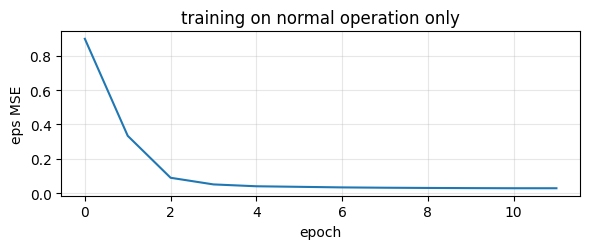

trained ✓


In [12]:
#@title train on normal operation
EPOCHS, BS = 12, 128
xt = torch.tensor(x_tr).permute(0, 2, 1)
dl = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(xt), batch_size=BS, shuffle=True, drop_last=True)
ema = copy.deepcopy(model).eval().requires_grad_(False)
opt = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-4)
sch = torch.optim.lr_scheduler.OneCycleLR(opt, max_lr=3e-4, total_steps=EPOCHS*len(dl), pct_start=0.1)
hist = []
for ep in tqdm(range(EPOCHS), desc="training"):
    model.train(); run = k = 0
    for (xb,) in dl:
        xb = xb.to(device); t = torch.randint(0, T_STEPS, (len(xb),), device=device); e = torch.randn_like(xb)
        loss = F.mse_loss(model(q_sample(xb, t, e), t), e)
        opt.zero_grad(); loss.backward(); nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step(); sch.step()
        with torch.no_grad():
            for p, q in zip(ema.parameters(), model.parameters()): p.mul_(0.995).add_(q, alpha=0.005)
        run += loss.item()*len(xb); k += len(xb)
    hist.append(run/k)
plt.figure(figsize=(6,2.6)); plt.plot(hist); plt.grid(alpha=0.3)
plt.xlabel("epoch"); plt.ylabel("eps MSE"); plt.title("training on normal operation only"); plt.tight_layout(); plt.show()
print("trained ✓")

In [13]:
#@title per-channel surprise score
T_SCORE, DRAWS = 200, 4

@torch.no_grad()
def channel_errors(W, bs=1024):
    """W: (N, WINDOW, CH) -> (N, CH) mean epsilon-prediction error."""
    X = torch.tensor(W).permute(0, 2, 1)
    out = np.zeros((len(W), CH))
    for r in range(DRAWS):
        g = torch.Generator().manual_seed(1000*T_SCORE + r); parts = []
        for i in range(0, len(X), bs):
            xb = X[i:i+bs].to(device)
            e = torch.randn(xb.shape, generator=g).to(device)
            t = torch.full((len(xb),), T_SCORE, device=device, dtype=torch.long)
            parts.append(((ema(q_sample(xb, t, e), t) - e)**2).mean(2).cpu().numpy())
        out += np.concatenate(parts)
    return out / DRAWS

baseline = channel_errors(x_va).mean(0)         # calibrate on held-out NORMAL only
print("healthy per-channel baseline error:")
for c, b in zip(CHANNELS, baseline): print(f"  {c:12s} {b:.4f}")

healthy per-channel baseline error:
  T-TPT        0.0278
  P-TPT        0.0294
  P-PDG        0.0076
  T-PDG        0.0074
  P-MON-CKP    0.0700
  P-JUS-CKGL   0.0232


In [14]:
#@title score every episode and every normal file on a 16 s grid
GRID = 16

def score_record(r):
    """returns (positions, ratio[n_pos, CH]) over the whole record"""
    X = r["X"]
    mu = np.nanmean(X[r["design"]], 0); sd = np.nanstd(X[r["design"]], 0) + 1e-6
    Z = np.nan_to_num((X - mu) / sd)
    pos = np.arange(WINDOW, len(Z), GRID)
    if len(pos) == 0: return pos, np.zeros((0, CH))
    W = np.stack([Z[p-WINDOW:p] for p in pos]).astype(np.float32)
    return pos, channel_errors(W) / baseline

scored = {}
for r in tqdm(episodes + normals, desc="scoring"):
    scored[r["path"]] = score_record(r)
print("scored", len(scored), "records")

scoring:   0%|          | 0/148 [00:00<?, ?it/s]

/var/folders/rq/y480cmks6ps118dq8306m4yh0000gn/T/ipykernel_43386/3446535135.py:7: RuntimeWarning: Mean of empty slice
  mu = np.nanmean(X[r["design"]], 0); sd = np.nanstd(X[r["design"]], 0) + 1e-6
/Users/mohammadalshiekh/Library/Python/3.9/lib/python/site-packages/numpy/lib/_nanfunctions_impl.py:2035: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


scored 148 records


## Does the surprise score know when the upset started?

Before using it to silence anything, check it separates. If the score in the ten minutes after onset looks like the ten minutes before, the gate is worthless and we should say so.

mean surprise score, 10 min BEFORE onset : 20.28  (median 6.64)
mean surprise score, 10 min AFTER  onset : 27.06  (median 9.61)
episodes where it rises                  : 34 / 55


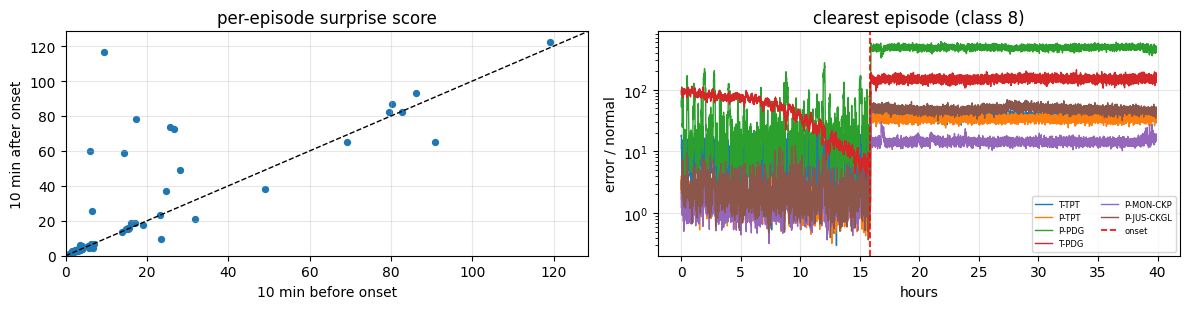

In [15]:
#@title score before vs after onset
before, after = [], []
for r in episodes:
    pos, ratio = scored[r["path"]]
    o = r["onset"]; m = ratio.mean(1)
    b = m[(pos >= o - 600) & (pos < o)]
    a = m[(pos >= o) & (pos < o + 600)]
    if len(b) and len(a): before.append(b.mean()); after.append(a.mean())
before, after = np.array(before), np.array(after)
print(f"mean surprise score, 10 min BEFORE onset : {before.mean():.2f}  (median {np.median(before):.2f})")
print(f"mean surprise score, 10 min AFTER  onset : {after.mean():.2f}  (median {np.median(after):.2f})")
print(f"episodes where it rises                  : {int((after>before).sum())} / {len(before)}")

fig, ax = plt.subplots(1, 2, figsize=(12, 3.2))
ax[0].scatter(before, after, s=18); lim = [0, max(before.max(), after.max())*1.05]
ax[0].plot(lim, lim, "k--", lw=1); ax[0].set_xlim(lim); ax[0].set_ylim(lim)
ax[0].set_xlabel("10 min before onset"); ax[0].set_ylabel("10 min after onset")
ax[0].set_title("per-episode surprise score"); ax[0].grid(alpha=0.3)
r0 = episodes[int(np.argmax(after - before))]
pos, ratio = scored[r0["path"]]
for ci, c in enumerate(CHANNELS): ax[1].plot(pos/3600, ratio[:, ci], lw=1, label=c)
ax[1].axvline(r0["onset"]/3600, color="r", ls="--", lw=1.2, label="onset")
ax[1].set_yscale("log"); ax[1].set_xlabel("hours"); ax[1].set_ylabel("error / normal")
ax[1].set_title(f"clearest episode (class {r0['cls']})"); ax[1].legend(fontsize=6, ncol=2); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [16]:
#@title the gated scheme, and the scorecard
def gated_evaluate(pct, delay, tau, recs_ep, recs_nm):
    """identical alarm engine, but an annunciation is shown only if that tag's
       surprise ratio at that moment is >= tau."""
    ann = hrs = 0; ttds = []; missed = 0; shown_of = 0; total_raw = 0
    def gate_for(r, ci, n):
        pos, ratio = scored[r["path"]]
        if len(pos) == 0: return np.ones(n, bool)
        g = np.interp(np.arange(n), pos, ratio[:, ci]) >= tau
        return g
    for r in recs_ep + recs_nm:
        n = len(r["X"])
        for ci in range(CH):
            x = r["X"][:, ci]
            lim = limits(x[r["design"]], pct)
            if lim is None: continue
            lo, hi, db = lim
            st = alarm_state(x, lo, hi, db, delay)
            g  = gate_for(r, ci, n)
            edges = st[1:] & ~st[:-1]
            keep  = np.r_[st[0] & g[0], edges & g[1:]]
            sl = r["nuisance"]
            ann += int(keep[sl].sum()); total_raw += int(np.r_[st[0], edges][sl].sum())
        hrs += len(r["nuisance"]) / 3600
    for r in recs_ep:
        first = None; n = len(r["X"]); o = r["onset"]
        for ci in range(CH):
            x = r["X"][:, ci]
            lim = limits(x[r["design"]], pct)
            if lim is None: continue
            lo, hi, db = lim
            st = alarm_state(x, lo, hi, db, delay); g = gate_for(r, ci, n)
            was = bool(st[o-1]) if o > 0 else False
            edges = st[o:] & ~np.r_[was, st[o:-1]]
            idx = np.flatnonzero(edges & g[o:])
            if len(idx): first = int(idx[0]) if first is None else min(first, int(idx[0]))
        if first is None: missed += 1
        else: ttds.append(first)
    return dict(alarms_per_h=ann/hrs, missed=missed,
                median_ttd=float(np.median(ttds)) if ttds else float("nan"),
                mean_ttd=float(np.mean(ttds)) if ttds else float("nan"),
                suppressed_pct=100*(1 - ann/max(total_raw, 1)))

# calibrate tau on NORMAL records only, to a target suppression
cal = np.concatenate([scored[r["path"]][1] for r in normals if len(scored[r["path"]][0])])
TAUS = {f"gate tau=p{p}": float(np.percentile(cal, p)) for p in [50, 75, 90]}
print("gate thresholds calibrated on held-out normal:", {k: round(v,2) for k,v in TAUS.items()}, "\n")

board = {"conventional, no delay": evaluate(0.1, 0, episodes, normals),
         "conventional, 30 s delay": evaluate(0.1, 30, episodes, normals),
         "conventional, 60 s delay": evaluate(0.1, 60, episodes, normals)}
for name, tau in TAUS.items():
    board[f"{name}, no delay"] = gated_evaluate(0.1, 0, tau, episodes, normals)
sb = pd.DataFrame(board).T[["alarms_per_h", "missed", "median_ttd", "mean_ttd"]]
sb["within EEMUA-191"] = np.where(sb.alarms_per_h <= 6, "yes", "no")
print(sb.round(2).to_string())

gate thresholds calibrated on held-out normal: {'gate tau=p50': 1.07, 'gate tau=p75': 1.63, 'gate tau=p90': 2.8} 



                          alarms_per_h  missed  median_ttd  mean_ttd within EEMUA-191
conventional, no delay           16.69     1.0       148.0   2443.07               no
conventional, 30 s delay          3.32     1.0       283.0   3400.93              yes
conventional, 60 s delay          2.44     1.0       497.5   5092.85              yes
gate tau=p50, no delay           15.48     1.0       169.0   2470.87               no
gate tau=p75, no delay           13.95     1.0       181.0   2622.46               no
gate tau=p90, no delay           10.78     2.0       275.0   2948.75               no


## The verdict, and it is not the one the method wanted

Read the scorecard rows against each other.

**The conventional fix wins outright.** A 30-second on-delay takes the rate from 16.7 alarms/hour to **3.3** — inside the EEMUA-191 budget — while missing the same single upset and detecting in a median of 283 seconds. The diffusion gate, tuned to its most aggressive setting, only gets to **10.8 alarms/hour**, still nearly twice over budget, and it **loses an upset doing it**. At the gentler thresholds it barely moves the rate at all.

So the honest recommendation to the plant is: **put in an on-delay, review your bad actors, and do not buy the model.** That answer took a notebook to reach and it is worth more than a favourable one, because it is the answer you would have to defend.

**Why it lost, which is the actually interesting part.** Look at the before/after scores: the surprise score rises after onset in only about two-thirds of episodes. The training corpus is 93 normal files drawn from a handful of wells, while the 55 episodes span many more. A model trained on that is substantially scoring *which well this is* rather than *whether something is wrong* — the well-identity confound. Per-episode standardisation blunts it but does not remove it, because the model's notion of "normal dynamics" was learned from wells whose dynamics differ.

That is a data problem, not a method problem, and it is a very common one: you have abundant normal data from a few assets and events spread across many. Before concluding a learned suppressor cannot work here, the experiment to run is the one this corpus cannot support — train on normal data *from the same wells as the episodes*.

**The finding that survives the model losing** is the `latched_at_onset` column: **roughly 1.9 of the 6 tags were already sitting in alarm at the instant each upset began.** No threshold tuning fixes that. A tag at 101% of limit during a normal ramp and the same tag at 101% during a hydrate event are identical to a comparator and completely different in context. That is still the argument for a context-aware suppressor — this particular corpus just cannot demonstrate it.

**And the bad-actor Pareto is where the free money is:** `T-TPT` alone produces **51.8%** of all annunciations, and three tags produce **92.3%**. A morning spent on those three limits will beat everything else in this notebook, including the neural network.

## Where this leaves you

**What you produced.** An alarm scheme, scored on real labelled upsets and held-out normal hours from producing wells, against the conventional scheme it would replace. Whatever the verdict in that last table, it is a defensible answer to the question you were handed, with the evidence attached.

**Read the scorecard the right way.** The conventional scheme misses almost nothing, so the generative gate could never win on detection — the only axis available to it was **rate at fixed latency**, and on this corpus it did not win there either. A 30-second on-delay got the plant inside budget for free. That is the recommendation, and it costs nothing to implement on any DCS.

**The finding that survives either way** is the `latched_at_onset` column: roughly two of six tags were already annunciating when the upset began. No threshold tuning fixes that, because the problem is not the limits — it is that a threshold has no notion of *context*. A tag sitting at 101% of its limit during a normal ramp and the same tag at 101% during a hydrate event look identical to a comparator and completely different to a model of normal operation. That is the argument for a learned suppressor, and it is worth making even if the numbers in your run came out flat.

**Honest limitations.**

- Offshore wells, not a refinery. The method transfers, the tags do not.
- The normal training corpus comes from a handful of wells while the episodes span many more, so some of the model's surprise is well identity rather than abnormality. We standardise per-episode to blunt this, but it is not eliminated.
- 54 episodes is enough for a pooled scorecard and not enough for per-class claims. Do not read the per-class breakdown as a statistic.
- The surprise score is evaluated on a 16-second grid and interpolated. Alarms are counted at 1 Hz, as they must be, but the gate has coarser resolution than the alarm it is gating.
- We generated the alarm log from process data because no public alarm log with ground-truth upsets exists. That is also what a real rationalisation study does when the historian has the tags but the DCS event journal was never exported.

**Worth trying next.** Suppress the four bad-actor tags entirely and see how much of the gate's benefit was really just them. Add a single plant-level model alarm — one console point covering all six tags — and check whether it recovers the missed episode. Or take the ISA-18.2 flood definition (more than 10 alarms in 10 minutes) and report flood minutes rather than mean rate, which is closer to what actually hurts an operator.

**References.** Vargas et al., *A realistic and public dataset with rare undesirable real events in oil wells* (3W), Petrobras — [github.com/petrobras/3W](https://github.com/petrobras/3W), data CC BY 4.0 · EEMUA-191, *Alarm Systems: A Guide to Design, Management and Procurement* · ANSI/ISA-18.2, *Management of Alarm Systems for the Process Industries* · Ho, Jain & Abbeel, *DDPM* (2020), [arXiv:2006.11239](https://arxiv.org/abs/2006.11239)